# California Residential Home Price Prediction
# Geographic Clustering with K Means

This notebook explores whether K means clustering on property coordinates adds useful geographic signal beyond County, City, and School District, by grouping properties into location based clusters.

In [10]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Section 1 - Setup and Data Loading

In [11]:
df_model = pd.read_csv('data/cleaned_data_with_district.csv')
print('Shape:', df_model.shape)

Shape: (397458, 23)


## Section 2 - Determining Cluster Count

Two checks are used to determine a reasonable number of clusters. First, the elbow method examines how much within cluster variance is reduced as cluster count increases. Second, since the ultimate goal is a useful pricing feature, average ClosePrice separation across clusters is checked directly for each candidate k value.

In [12]:
coords = df_model[['Latitude', 'Longitude']]

inertias = []
k_range = range(2, 21)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertias.append(km.inertia_)

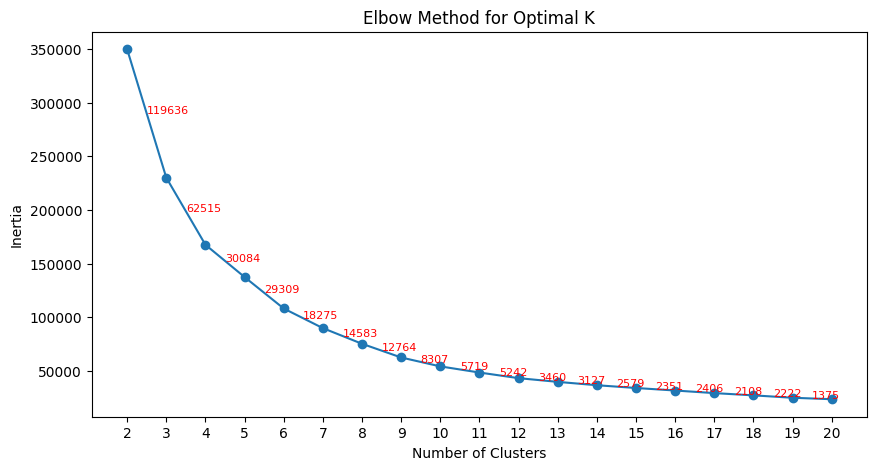

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)

for i in range(len(inertias) - 1):
    slope = inertias[i] - inertias[i+1]
    mid_x = (list(k_range)[i] + list(k_range)[i+1]) / 2
    mid_y = (inertias[i] + inertias[i+1]) / 2
    plt.annotate(f'{slope:.0f}', (mid_x, mid_y), fontsize=8, color='red')

plt.show()

In [14]:
results = []

for k in range(2, 21):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords)
    price_range = df_model.groupby(labels)['ClosePrice'].mean().max() - df_model.groupby(labels)['ClosePrice'].mean().min()
    results.append({'k': k, 'price_range': price_range})

results_df = pd.DataFrame(results)
print(results_df)

     k   price_range
0    2  2.092109e+05
1    3  3.484737e+05
2    4  6.736395e+05
3    5  6.454664e+05
4    6  1.024346e+06
5    7  1.024384e+06
6    8  1.036868e+06
7    9  1.037226e+06
8   10  1.298787e+06
9   11  1.298787e+06
10  12  1.295933e+06
11  13  1.300556e+06
12  14  1.304538e+06
13  15  1.343212e+06
14  16  1.338024e+06
15  17  1.335385e+06
16  18  1.647440e+06
17  19  1.629982e+06
18  20  1.654739e+06


## Section 3 - Applying K Means Clustering

Testing cluster counts from 2 through 20 shows a meaningful jump in average price separation between clusters at k equals 10, after which additional clusters through 19 provide little further separation. K equals 10 is selected as it captures this jump without adding unnecessary granularity.

In [15]:
kmeans_final = KMeans(n_clusters=10, random_state=42, n_init=10)
df_model['GeoCluster'] = kmeans_final.fit_predict(coords)

print(df_model['GeoCluster'].value_counts())

GeoCluster
2    92148
9    79054
8    60051
4    51961
0    43820
1    24853
3    19284
7     9010
5     8759
6     8518
Name: count, dtype: int64


## Section 4 - Summary

GeoCluster is added as a new categorical feature capturing location based pricing patterns beyond what County, City, and School District already provide. Testing across a range of cluster counts confirmed that k equals 10 captures the most meaningful jump in price separation before returns diminish.

In [16]:
df_model.to_csv('data/cleaned_data_final.csv', index=False)
print('Saved.')

Saved.


In [17]:
import pickle

with open('data/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

print('KMeans model saved.')

KMeans model saved.
